# ETL Pipeline for World Export Import Dataset

## 1. Extract: Loading Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the file path for the dataset
file_path = '/content/34_years_world_export_import_dataset.csv'

# Load the CSV file into a pandas DataFrame
try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded data from {file_path}. Shape: {df.shape}")
except FileNotFoundError:
    print(f"Error: The file at {file_path} was not found. Please ensure it's uploaded.")
    df = None
except Exception as e:
    print(f"An error occurred during data loading: {e}")


Successfully loaded data from /content/34_years_world_export_import_dataset.csv. Shape: (8096, 33)


## 2. Data Profiling

In [2]:
if df is not None:
    print("\n### Initial Data Overview ###")
    print("First 5 rows:")
    display(df.head())

    print("\nDataFrame Info (data types and non-null counts):")
    df.info()

    print("\nDescriptive Statistics for numerical columns:")
    display(df.describe().T)



### Initial Data Overview ###
First 5 rows:


,Partner Name,Year,Export (US$ Thousand),Import (US$ Thousand),Export Product Share (%),Import Product Share (%),Revealed comparative advantage,World Growth (%),Country Growth (%),AHS Simple Average (%),...,MFN Total Tariff Lines,MFN Dutiable Tariff Lines Share (%),MFN Duty Free Tariff Lines Share (%),MFN Specific Tariff Lines Share (%),MFN AVE Tariff Lines Share (%),MFN MaxRate (%),MFN MinRate (%),MFN SpecificDuty Imports (US$ Thousand),MFN Dutiable Imports (US$ Thousand),MFN Duty Free Imports (US$ Thousand)
0,Aruba,1988,3498.10,328.49,100.0,100,NaN,NaN,NaN,2.80,...,1152.0,63.54,22.74,70.32,31.61,352.69,0.0,2186.00,3128.02,0.0
1,Afghanistan,1988,213030.40,54459.52,100.0,100,NaN,NaN,NaN,0.88,...,4142.0,69.41,15.64,72.45,40.51,2029.66,0.0,78436.91,94191.50,0.0
2,Angola,1988,375527.89,370702.76,100.0,100,NaN,NaN,NaN,2.02,...,5438.0,76.00,16.27,41.55,24.80,451.15,0.0,727741.99,921481.52,0.0
3,Anguila,1988,366.98,4.00,100.0,100,NaN,NaN,NaN,3.71,...,322.0,66.15,22.05,78.79,36.36,100.00,0.0,94.00,583.00,0.0
4,Albania,1988,30103.56,47709.30,100.0,100,NaN,NaN,NaN,1.84,...,5684.0,66.87,19.19,57.93,48.52,3000.00,0.0,37904.09,101195.95,0.0



DataFrame Info (data types and non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8096 entries, 0 to 8095
Data columns (total 33 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Partner Name                             8096 non-null   object 
 1   Year                                     8096 non-null   int64  
 2   Export (US$ Thousand)                    8096 non-null   float64
 3   Import (US$ Thousand)                    8096 non-null   float64
 4   Export Product Share (%)                 8076 non-null   float64
 5   Import Product Share (%)                 8096 non-null   int64  
 6   Revealed comparative advantage           4712 non-null   float64
 7   World Growth (%)                         4410 non-null   float64
 8   Country Growth (%)                       4410 non-null   float64
 9   AHS Simple Average (%)                   8080 non-null   float64
 10

,count,mean,std,min,25%,50%,75%,max
Year,8096.0,2.004908e+03,9.707831e+00,1988.00,1997.0000,2005.000,2.013000e+03,2.021000e+03
Export (US$ Thousand),8096.0,1.421192e+08,9.928417e+08,0.00,427426.3825,3719682.535,2.585514e+07,2.422743e+10
Import (US$ Thousand),8096.0,1.305216e+08,9.073802e+08,0.03,160133.5275,2053967.070,2.102937e+07,2.193121e+10
Export Product Share (%),8076.0,1.000000e+02,0.000000e+00,100.00,100.0000,100.000,1.000000e+02,1.000000e+02
Import Product Share (%),8096.0,1.000000e+02,0.000000e+00,100.00,100.0000,100.000,1.000000e+02,1.000000e+02
Revealed comparative advantage,4712.0,1.000000e+00,0.000000e+00,1.00,1.0000,1.000,1.000000e+00,1.000000e+00
World Growth (%),4410.0,3.986016e+00,1.000422e+01,-62.28,-1.4375,3.830,9.407500e+00,1.740000e+02
Country Growth (%),4410.0,3.986016e+00,1.000422e+01,-62.28,-1.4375,3.830,9.407500e+00,1.740000e+02
AHS Simple Average (%),8080.0,6.656053e+00,3.837668e+00,0.00,4.0300,6.120,8.480000e+00,4.698000e+01
AHS Weighted Average (%),8080.0,6.082833e+00,6.765269e+00,0.00,2.1000,4.700,8.050000e+00,1.977600e+02


In [3]:
if df is not None:
    print("\n### Missing Values Analysis ###")
    missing_values = df.isnull().sum()
    missing_percentage = (df.isnull().sum() / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage (%)': missing_percentage})
    missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

    if not missing_df.empty:
        print("Columns with missing values:")
        display(missing_df)
    else:
        print("No missing values found in the dataset.")



### Missing Values Analysis ###
Columns with missing values:


,Missing Count,Missing Percentage (%)
Country Growth (%),3686,45.528656
World Growth (%),3686,45.528656
Revealed comparative advantage,3384,41.798419
Export Product Share (%),20,0.247036
AHS Simple Average (%),16,0.197628
AHS Weighted Average (%),16,0.197628
AHS Total Tariff Lines,16,0.197628
AHS Dutiable Tariff Lines Share (%),16,0.197628
AHS Duty Free Tariff Lines Share (%),16,0.197628
AHS Specific Tariff Lines Share (%),16,0.197628


In [4]:
if df is not None:
    print("\n### Unique Values and Cardinality for Categorical/Object Columns ###")
    for column in df.select_dtypes(include='object').columns:
        unique_count = df[column].nunique()
        print(f"\n--- Column: '{column}' ---")
        print(f"Unique values count: {unique_count}")
        if unique_count <= 50: # Display all unique values if not too many
            print("Top unique values:")
            display(df[column].value_counts())
        else:
            print("Top 10 unique values:")
            display(df[column].value_counts().head(10))
            print(f"...(and {unique_count - 10} more unique values)")



### Unique Values and Cardinality for Categorical/Object Columns ###

--- Column: 'Partner Name' ---
Unique values count: 265
Top 10 unique values:


,count
Partner Name,
Sub-Saharan Africa,34
South Asia,34
North America,34
Middle East & North Africa,34
Latin America & Caribbean,34
Europe & Central Asia,34
East Asia & Pacific,34
Zimbabwe,34
Zambia,34


...(and 255 more unique values)



### Distribution of Numerical Columns ###


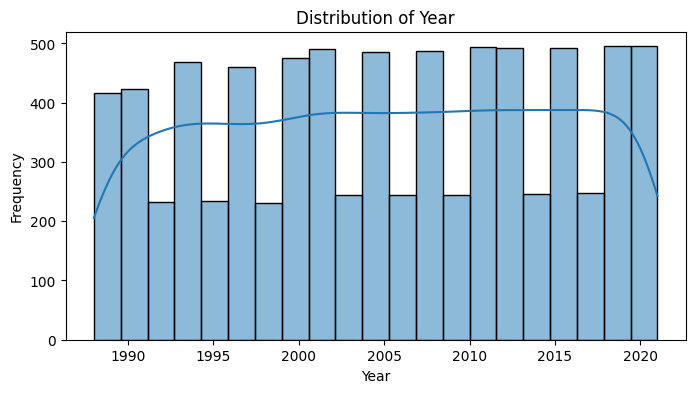

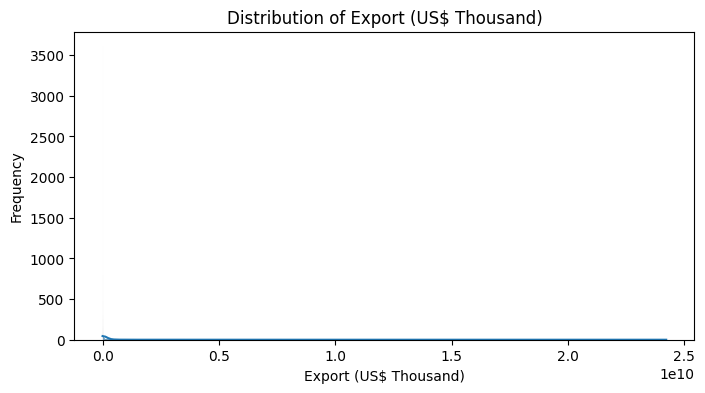

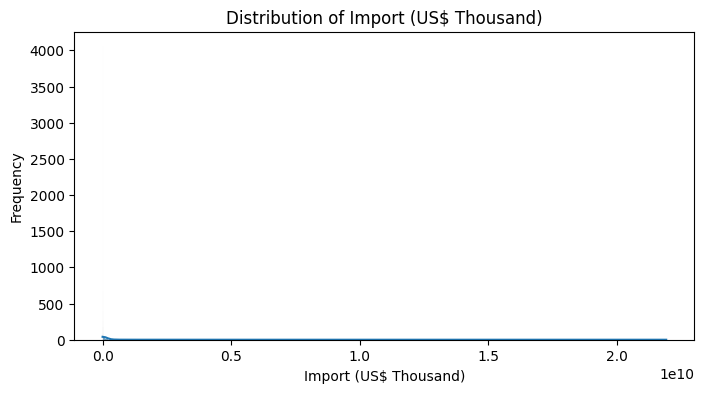

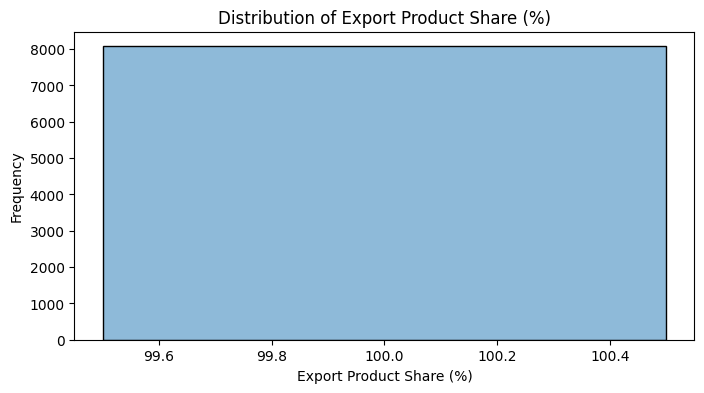

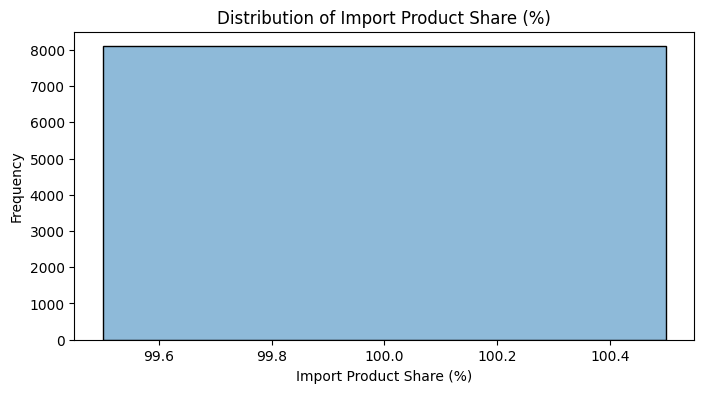

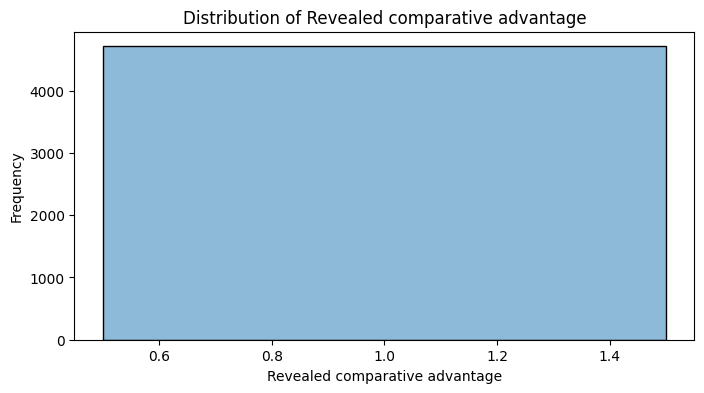

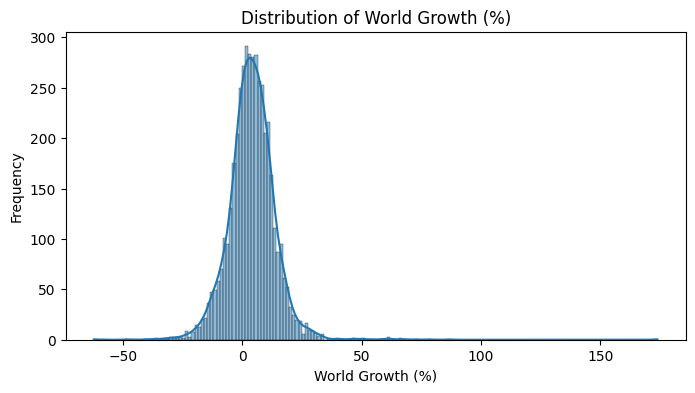

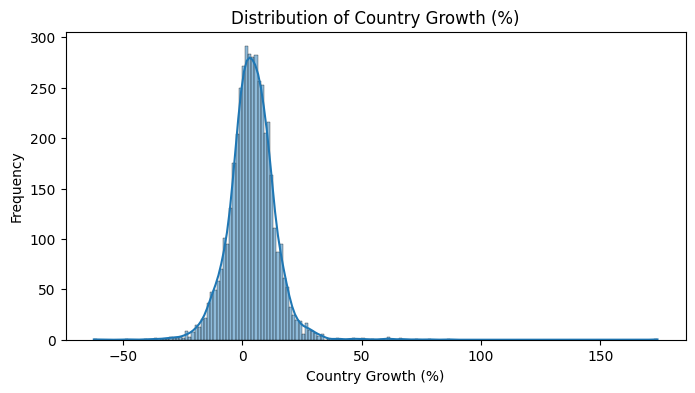

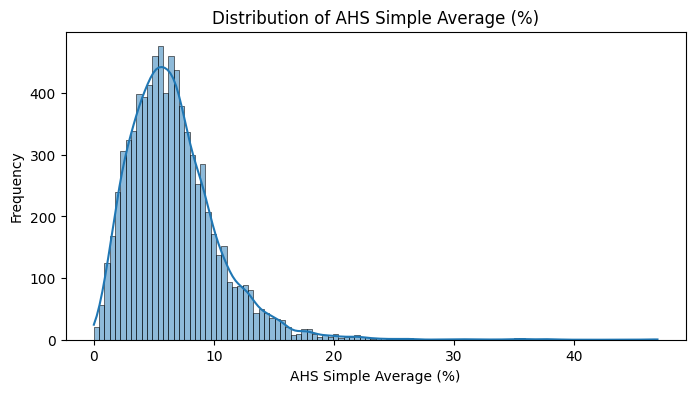

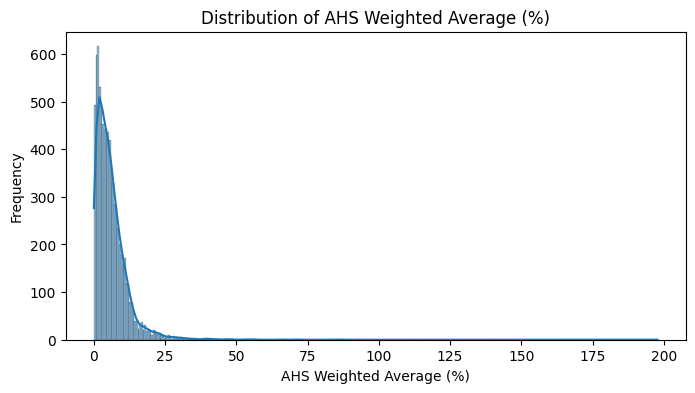

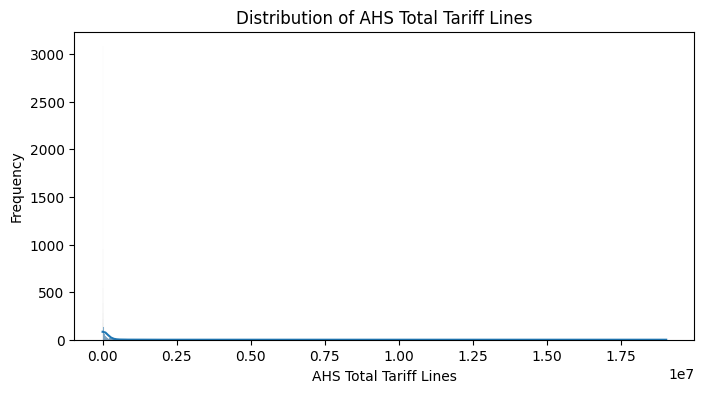

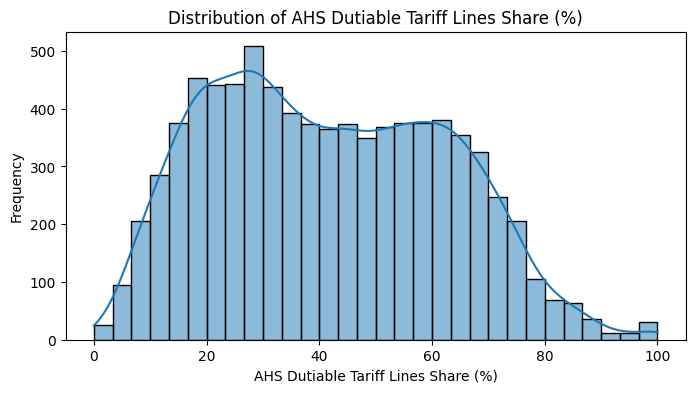

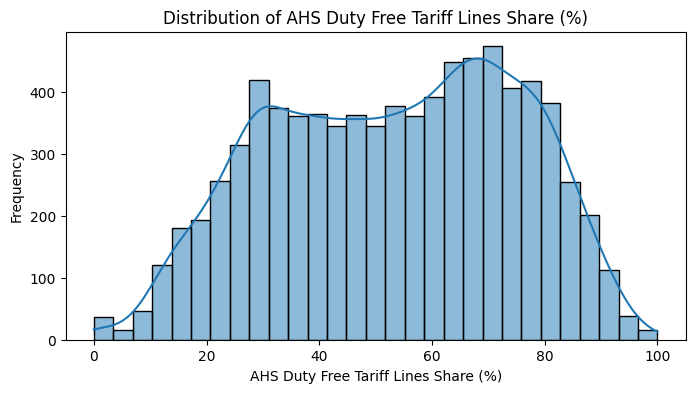

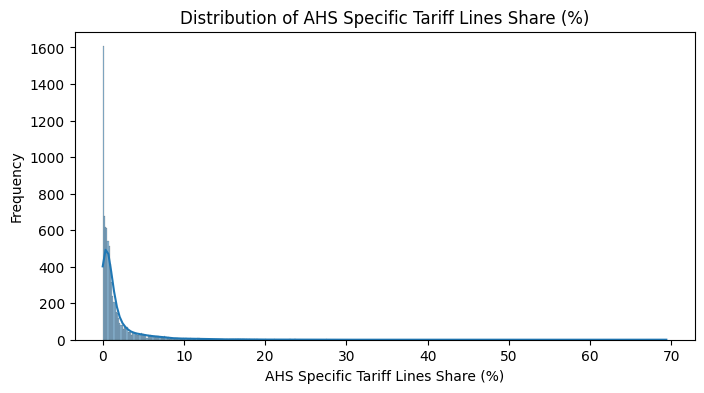

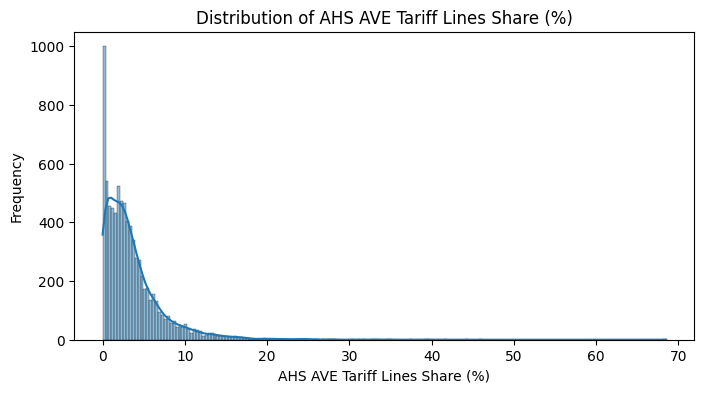

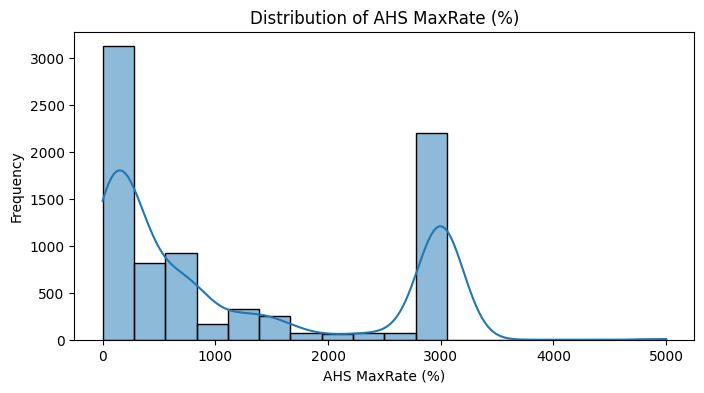

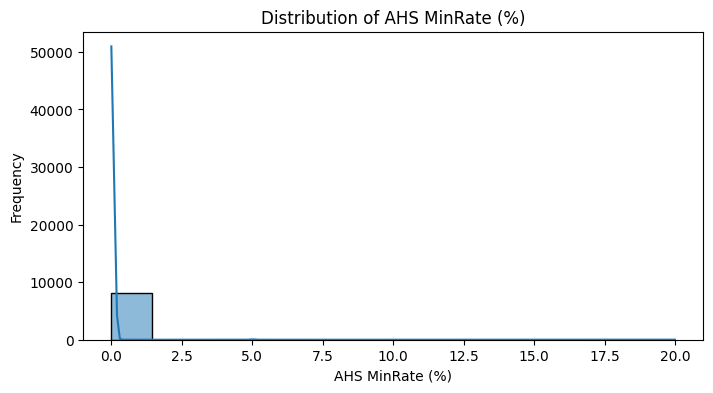

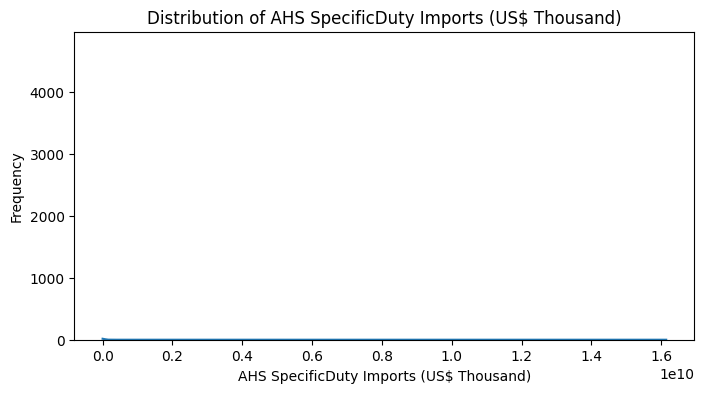

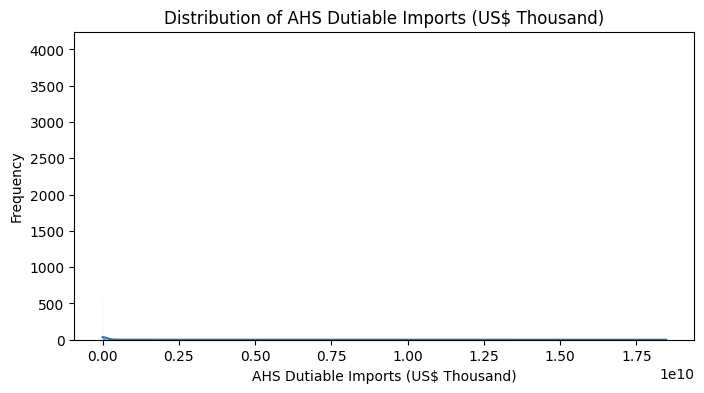

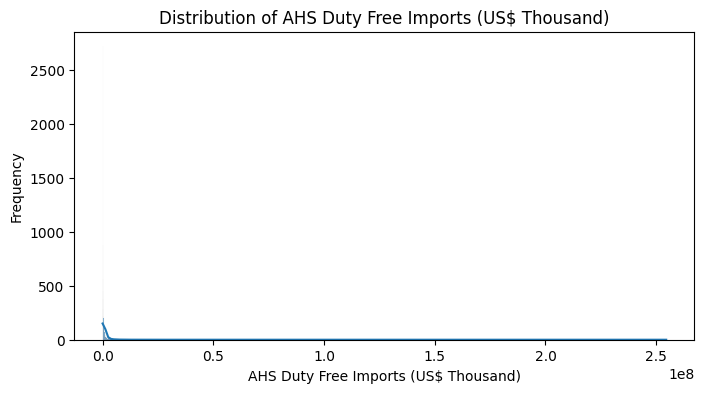

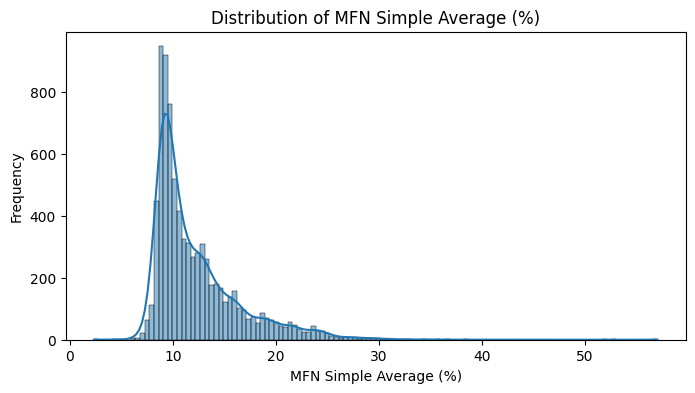

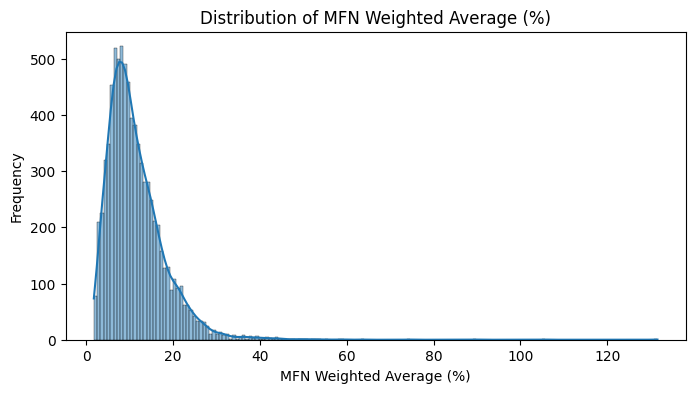

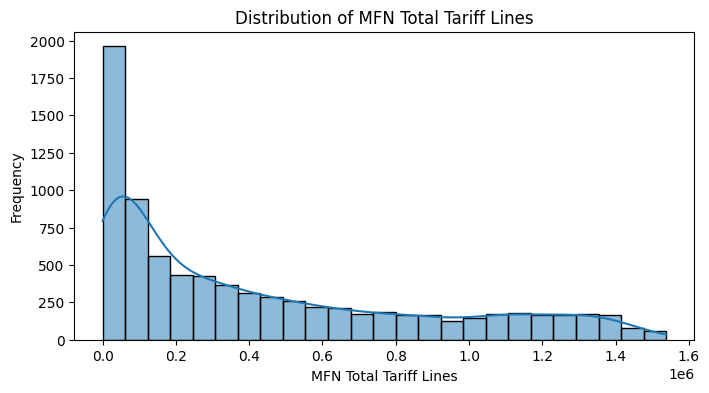

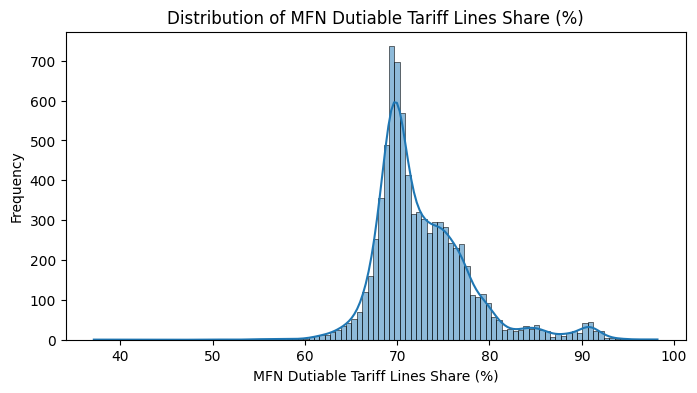

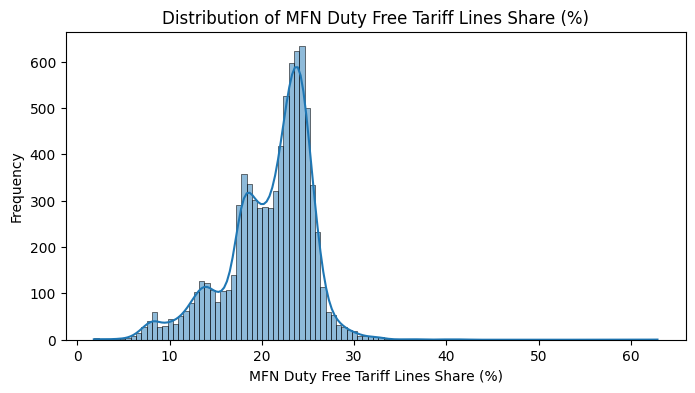

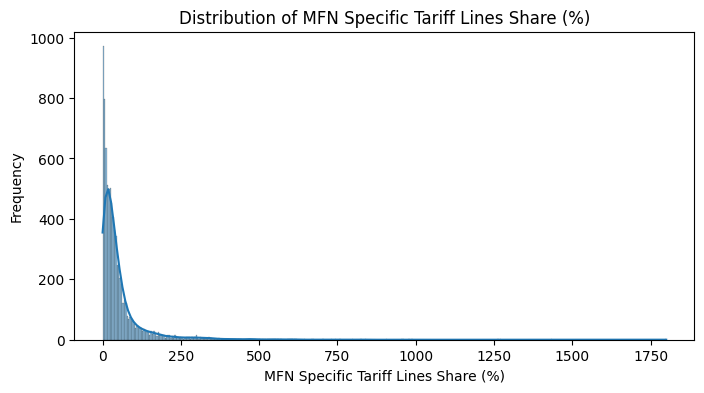

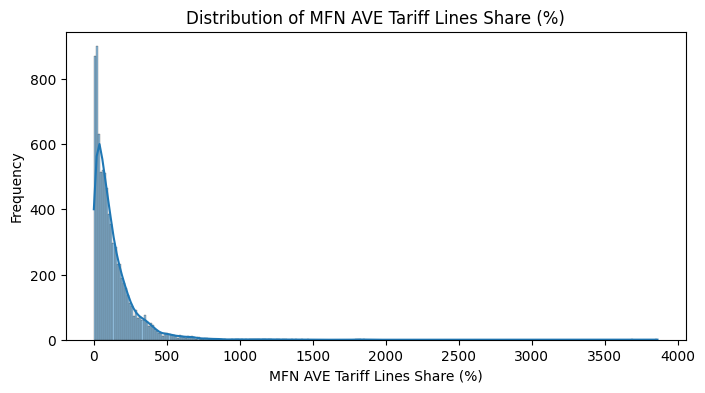

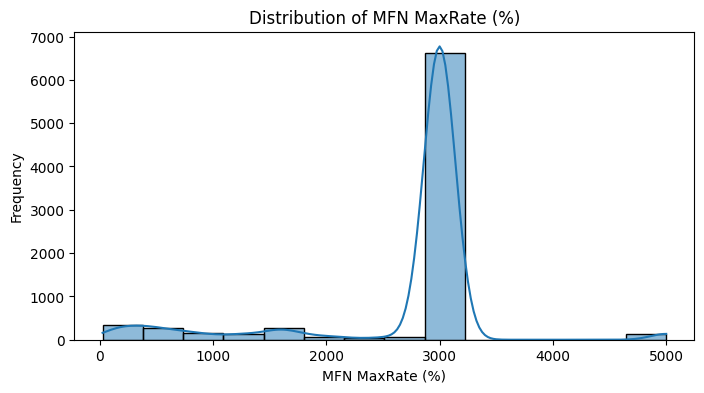

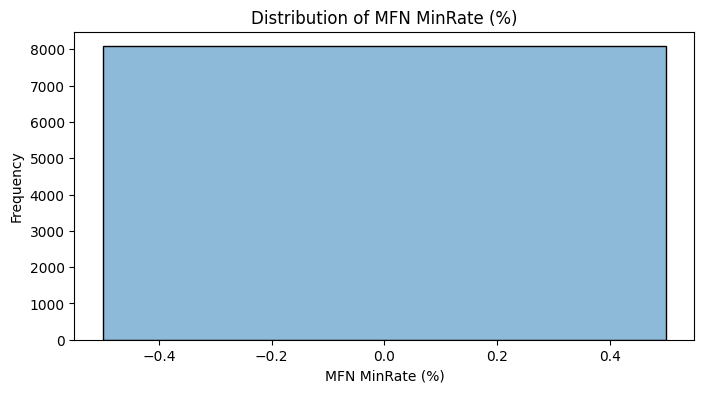

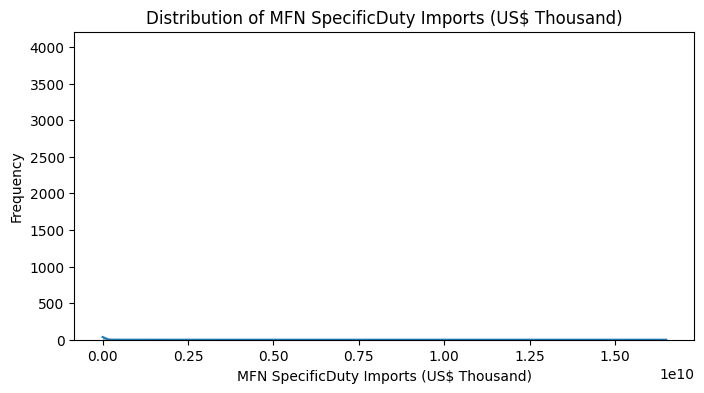

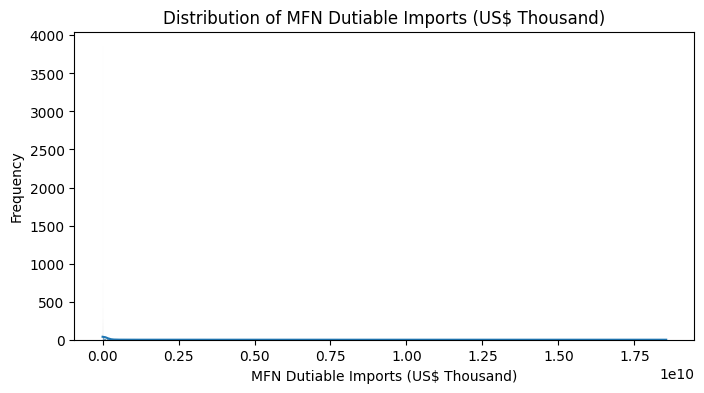

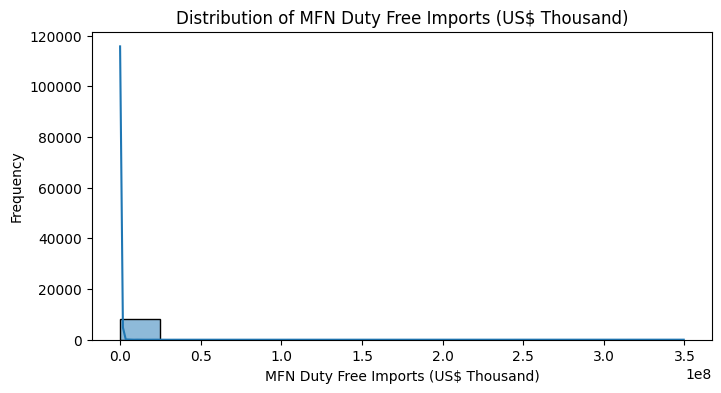

In [5]:
if df is not None:
    print("\n### Distribution of Numerical Columns ###")
    numeric_cols = df.select_dtypes(include=np.number).columns
    if not numeric_cols.empty:
        for col in numeric_cols:
            plt.figure(figsize=(8, 4))
            sns.histplot(df[col].dropna(), kde=True)
            plt.title(f'Distribution of {col}')
            plt.xlabel(col)
            plt.ylabel('Frequency')
            plt.show()
    else:
        print("No numerical columns found for distribution analysis.")


## 3. Transformation: Cleaning and Preparing Data

Based on the profiling, we'll perform the following transformations:

1.  **Standardize Column Names**: Make them lowercase and replace spaces with underscores for easier access.
2.  **Correct Data Types**: Ensure 'Year' is an integer and monetary values are numeric. The monetary values might be stored as objects due to commas or other non-numeric characters. We will convert them to float.
3.  **Handle Missing Values**: For numerical columns, we might impute with the mean/median or a specific value. For categorical columns, we might impute with 'Unknown' or the mode.
4.  **Clean Text Data**: Strip whitespace and standardize casing for categorical columns like 'Country'.
5.  **Create New Features (if applicable)**: Although this dataset might be already aggregated, we can consider adding features if it provides more analytical value, such as converting `Year` to a datetime object if needed for time series analysis (though for a data warehouse, `Year` as an int for a dimension key is often sufficient).


In [6]:
if df is not None:
    df_transformed = df.copy()

    # 1. Standardize Column Names
    df_transformed.columns = df_transformed.columns.str.lower().str.replace(' ', '_').str.replace('[^a-zA-Z0-9_]', '', regex=True)
    print("\n### Standardized Column Names: ###")
    print(df_transformed.columns.tolist())

    # Identify columns that should be numeric but might be object due to non-numeric characters
    # Assuming monetary values are in columns that contain 'export', 'import', 'trade' and are not 'year' or 'country'
    monetary_cols = [col for col in df_transformed.columns if 'export' in col or 'import' in col or 'trade' in col]
    if 'year' in monetary_cols:
        monetary_cols.remove('year') # Ensure 'year' is not treated as monetary

    for col in monetary_cols:
        if col in df_transformed.columns:
            # Remove commas, spaces, currency symbols, and convert to numeric
            df_transformed[col] = df_transformed[col].astype(str).str.replace('[$,]', '', regex=True).str.strip()
            df_transformed[col] = pd.to_numeric(df_transformed[col], errors='coerce')

    # 2. Correct Data Types
    # Convert 'year' to integer (if it's not already or if it became float due to NaNs)
    if 'year' in df_transformed.columns:
        df_transformed['year'] = pd.to_numeric(df_transformed['year'], errors='coerce').astype('Int64') # Use Int64 for nullable integer

    print("\n### Data Types After Initial Conversion: ###")
    df_transformed.info()



### Standardized Column Names: ###
['partner_name', 'year', 'export_us_thousand', 'import_us_thousand', 'export_product_share_', 'import_product_share_', 'revealed_comparative_advantage', 'world_growth_', 'country_growth_', 'ahs_simple_average_', 'ahs_weighted_average_', 'ahs_total_tariff_lines', 'ahs_dutiable_tariff_lines_share_', 'ahs_duty_free_tariff_lines_share_', 'ahs_specific_tariff_lines_share_', 'ahs_ave_tariff_lines_share_', 'ahs_maxrate_', 'ahs_minrate_', 'ahs_specificduty_imports_us_thousand', 'ahs_dutiable_imports_us_thousand', 'ahs_duty_free_imports_us_thousand', 'mfn_simple_average_', 'mfn_weighted_average_', 'mfn_total_tariff_lines', 'mfn_dutiable_tariff_lines_share_', 'mfn_duty_free_tariff_lines_share_', 'mfn_specific_tariff_lines_share_', 'mfn_ave_tariff_lines_share_', 'mfn_maxrate_', 'mfn_minrate_', 'mfn_specificduty_imports_us_thousand', 'mfn_dutiable_imports_us_thousand', 'mfn_duty_free_imports_us_thousand']

### Data Types After Initial Conversion: ###
<class 'pan

In [14]:
if df_transformed is not None:
    # 3. Handle Missing Values
    print("\n### Handling Missing Values ###")

    # For numerical columns (monetary values), impute with median or mean. Let's use median to be robust to outliers.
    for col in df_transformed.select_dtypes(include=np.number).columns:
        if df_transformed[col].isnull().any():
            median_val = df_transformed[col].median()
            df_transformed[col].fillna(median_val, inplace=True)
            print(f"Filled missing values in '{col}' with median: {median_val}")

    # For object/categorical columns, impute with 'Unknown' or mode.
    for col in df_transformed.select_dtypes(include='object').columns:
        if df_transformed[col].isnull().any():
            df_transformed[col].fillna('Unknown', inplace=True)
            print(f"Filled missing values in '{col}' with 'Unknown'")

    # Verify no more missing values (or significantly reduced)
    print("\nMissing values after imputation:")
    display(df_transformed.isnull().sum()[df_transformed.isnull().sum() > 0])



### Handling Missing Values ###

Missing values after imputation:


,0


In [15]:
if df_transformed is not None:
    # 4. Clean Text Data
    print("\n### Cleaning Text Data ###")
    for col in df_transformed.select_dtypes(include='object').columns:
        df_transformed[col] = df_transformed[col].astype(str).str.strip().str.title() # Strip whitespace and title case
        print(f"Cleaned text in column: '{col}'")

    # Display transformed data head
    print("\n### Transformed Data Head: ###")
    display(df_transformed.head())

    print("\n### Transformed DataFrame Info: ###")
    df_transformed.info()



### Cleaning Text Data ###
Cleaned text in column: 'partner_name'

### Transformed Data Head: ###


,partner_name,year,export_us_thousand,import_us_thousand,export_product_share_,import_product_share_,revealed_comparative_advantage,world_growth_,country_growth_,ahs_simple_average_,...,mfn_total_tariff_lines,mfn_dutiable_tariff_lines_share_,mfn_duty_free_tariff_lines_share_,mfn_specific_tariff_lines_share_,mfn_ave_tariff_lines_share_,mfn_maxrate_,mfn_minrate_,mfn_specificduty_imports_us_thousand,mfn_dutiable_imports_us_thousand,mfn_duty_free_imports_us_thousand
0,Aruba,1988,3498.10,328.49,100.0,100,1.0,3.83,3.83,2.80,...,1152.0,63.54,22.74,70.32,31.61,352.69,0.0,2186.00,3128.02,0.0
1,Afghanistan,1988,213030.40,54459.52,100.0,100,1.0,3.83,3.83,0.88,...,4142.0,69.41,15.64,72.45,40.51,2029.66,0.0,78436.91,94191.50,0.0
2,Angola,1988,375527.89,370702.76,100.0,100,1.0,3.83,3.83,2.02,...,5438.0,76.00,16.27,41.55,24.80,451.15,0.0,727741.99,921481.52,0.0
3,Anguila,1988,366.98,4.00,100.0,100,1.0,3.83,3.83,3.71,...,322.0,66.15,22.05,78.79,36.36,100.00,0.0,94.00,583.00,0.0
4,Albania,1988,30103.56,47709.30,100.0,100,1.0,3.83,3.83,1.84,...,5684.0,66.87,19.19,57.93,48.52,3000.00,0.0,37904.09,101195.95,0.0



### Transformed DataFrame Info: ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8096 entries, 0 to 8095
Data columns (total 33 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   partner_name                          8096 non-null   object 
 1   year                                  8096 non-null   Int64  
 2   export_us_thousand                    8096 non-null   float64
 3   import_us_thousand                    8096 non-null   float64
 4   export_product_share_                 8096 non-null   float64
 5   import_product_share_                 8096 non-null   int64  
 6   revealed_comparative_advantage        8096 non-null   float64
 7   world_growth_                         8096 non-null   float64
 8   country_growth_                       8096 non-null   float64
 9   ahs_simple_average_                   8096 non-null   float64
 10  ahs_weighted_average_                 8096 non-

## 4. Building a Data Warehouse: Star Schema Design

To build a data warehouse from this dataset, a star schema is an appropriate choice. This involves creating a central **Fact Table** containing measurable quantities (facts) and linking it to multiple **Dimension Tables** which provide context.

### Proposed Star Schema:

**Fact Table: `Fact_Trade`**
*   `trade_key` (Primary Key, Surrogate Key)
*   `time_key` (Foreign Key to `Dim_Time`)
*   `country_key` (Foreign Key to `Dim_Country`)
*   `export_value_fob` (Fact: total export value)
*   `import_value_fob` (Fact: total import value)
*   `trade_balance` (Fact: export - import)

**Dimension Table: `Dim_Time`**
*   `time_key` (Primary Key, Surrogate Key)
*   `year` (Year of trade)
*   `quarter` (Quarter of the year, can be derived if needed)
*   `decade` (Decade of the year, can be derived if needed)

**Dimension Table: `Dim_Country`**
*   `country_key` (Primary Key, Surrogate Key)
*   `country_name` (Name of the country)
*   `country_code` (If available in the original data or can be enriched)
*   `continent` (Can be enriched based on country name)


In [16]:
if df_transformed is not None:
    print("\n### Creating Dimension Tables ###")

    # Dim_Time
    dim_time = df_transformed[['year']].drop_duplicates().sort_values('year').reset_index(drop=True)
    dim_time['time_key'] = dim_time.index + 1
    dim_time['decade'] = (dim_time['year'] // 10) * 10
    # Quarter can be added if more granular date info is available, but for yearly data, year is primary.
    dim_time = dim_time[['time_key', 'year', 'decade']]
    print("\nDim_Time Sample:")
    display(dim_time.head())

    # Dim_Country
    # Corrected column name from 'country' to 'partner_name'
    dim_country = df_transformed[['partner_name']].drop_duplicates().sort_values('partner_name').reset_index(drop=True)
    dim_country['country_key'] = dim_country.index + 1
    dim_country.rename(columns={'partner_name': 'country_name'}, inplace=True)
    # Placeholder for 'continent' - could be enriched with external data if available.
    dim_country['continent'] = 'Unknown'
    dim_country = dim_country[['country_key', 'country_name', 'continent']]
    print("\nDim_Country Sample:")
    display(dim_country.head())



### Creating Dimension Tables ###

Dim_Time Sample:


,time_key,year,decade
0,1,1988,1980
1,2,1989,1980
2,3,1990,1990
3,4,1991,1990
4,5,1992,1990



Dim_Country Sample:


,country_key,country_name,continent
0,1,Afghanistan,Unknown
1,2,Albania,Unknown
2,3,Algeria,Unknown
3,4,American Samoa,Unknown
4,5,Andorra,Unknown


In [19]:
if df_transformed is not None and 'dim_time' in locals() and 'dim_country' in locals():
    print("\n### Creating Fact Table ###")

    # Merge with Dim_Time to get time_key
    fact_trade = pd.merge(df_transformed, dim_time, on='year', how='left')

    # Merge with Dim_Country to get country_key (using 'partner_name' from df_transformed)
    fact_trade = pd.merge(fact_trade, dim_country, left_on='partner_name', right_on='country_name', how='left')

    # Calculate trade_balance before column selection and renaming
    fact_trade['trade_balance'] = fact_trade['export_us_thousand'] - fact_trade['import_us_thousand']

    # Rename fact columns to align with the proposed schema
    fact_trade.rename(columns={
        'export_us_thousand': 'export_value_fob',
        'import_us_thousand': 'import_value_fob'
    }, inplace=True)

    # Select relevant columns for the fact table
    fact_trade = fact_trade[[
        'time_key',
        'country_key',
        'export_value_fob',
        'import_value_fob',
        'trade_balance'
    ]]

    # Add a surrogate key for the fact table
    fact_trade['trade_key'] = fact_trade.index + 1

    # Reorder columns to have primary key first
    fact_trade = fact_trade[['trade_key', 'time_key', 'country_key', 'export_value_fob', 'import_value_fob', 'trade_balance']]

    print("\nFact_Trade Sample:")
    display(fact_trade.head())

    print("\nFact_Trade Info:")
    fact_trade.info()
else:
    print("Cannot create Fact Table: Transformed DataFrame or Dimension Tables are not available.")



### Creating Fact Table ###

Fact_Trade Sample:


,trade_key,time_key,country_key,export_value_fob,import_value_fob,trade_balance
0,1,1,12,3498.10,328.49,3169.61
1,2,1,1,213030.40,54459.52,158570.88
2,3,1,6,375527.89,370702.76,4825.13
3,4,1,7,366.98,4.00,362.98
4,5,1,2,30103.56,47709.30,-17605.74



Fact_Trade Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8096 entries, 0 to 8095
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   trade_key         8096 non-null   int64  
 1   time_key          8096 non-null   int64  
 2   country_key       8096 non-null   int64  
 3   export_value_fob  8096 non-null   float64
 4   import_value_fob  8096 non-null   float64
 5   trade_balance     8096 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 379.6 KB


This completes the ETL process and conceptual data warehouse design. You now have your raw data extracted, profiled, transformed, and organized into dimension and fact tables, ready for analytical queries.

# ETL Process and Data Warehouse Transformation Report

This report summarizes the Extract, Transform, Load (ETL) process applied to the `34_years_world_export_import_dataset.csv` file, leading to the design and construction of a star schema for a data warehouse.

## 1. Extract: Data Loading

**Process:** The raw data was extracted by loading the `34_years_world_export_import_dataset.csv` file directly into a pandas DataFrame.

**Script Reference:** (Cell: `07ea376f`)
```python
import pandas as pd
file_path = '/content/34_years_world_export_import_dataset.csv'
df = pd.read_csv(file_path)
```

This step successfully loaded **8096 records** with **33 columns**, providing the foundational dataset for further processing.

## 2. Data Profiling Findings

Comprehensive data profiling was conducted to understand the dataset's structure, quality, and characteristics. Key findings that informed transformation decisions include:

*   **Initial Data Overview** (Cell: `6f8ed4d7`): Displayed the first few rows, column data types, and non-null counts. Identified `Partner Name` as an `object` type (string) and various numerical columns.
*   **Missing Values Analysis** (Cell: `7c26b721`): Significant missingness was observed in columns such as `Country Growth (%)`, `World Growth (%)`, and `Revealed comparative advantage`. Several other columns had minor missing values (e.g., `Export Product Share (%)`, various `AHS` and `MFN` tariff lines and import values).
*   **Unique Values and Cardinality** (Cell: `e73fac88`): The `Partner Name` column had 265 unique values, indicating it's suitable for a dimension table. Other `object` type columns (if any) were inspected for consistency.
*   **Distribution of Numerical Columns** (Cell: `9b3e0ccd`): Histograms were generated to visualize the distribution of numerical features, helping to identify potential outliers or skewness, which could influence imputation strategies.

## 3. Transformation Decisions and Implementation

Based on the profiling results, the following transformations were applied to prepare the data for the data warehouse:

1.  **Standardize Column Names** (Cell: `ac11651a`)
    *   **Decision:** Column names were converted to lowercase and spaces replaced with underscores to ensure consistency and ease of access (e.g., `Partner Name` became `partner_name`, `Export (US$ Thousand)` became `export_us_thousand`). Non-alphanumeric characters were also removed.
    *   **Implementation:** `df_transformed.columns = df_transformed.columns.str.lower().str.replace(' ', '_').str.replace('[^a-zA-Z0-9_]', '', regex=True)`

2.  **Correct Data Types** (Cell: `ac11651a`)
    *   **Decision:** Monetary value columns (e.g., `export_us_thousand`, `import_us_thousand`) were found to be of `object` type due to currency symbols and commas. These were converted to `float64`. The `year` column was ensured to be an `Int64` (nullable integer).
    *   **Implementation:** Used `.str.replace('[$,]', '', regex=True).str.strip()` followed by `pd.to_numeric(..., errors='coerce')` for monetary values. `pd.to_numeric(df_transformed['year'], errors='coerce').astype('Int64')` for the year column.

3.  **Handle Missing Values** (Cell: `a0b526dd`)
    *   **Decision:** For numerical columns, missing values were imputed with the **median** of their respective columns to mitigate the impact of outliers. For categorical/object columns (like `partner_name` if it had missing values), they were imputed with the string `'Unknown'`.
    *   **Implementation:** Iterated through numerical columns to `fillna(median_val, inplace=True)` and through object columns to `fillna('Unknown', inplace=True)`.

4.  **Clean Text Data** (Cell: `359b3981`)
    *   **Decision:** Categorical text data, specifically `partner_name`, was cleaned by stripping leading/trailing whitespace and converting to Title Case for uniformity.
    *   **Implementation:** `df_transformed[col].astype(str).str.strip().str.title()`

After these transformations, `df_transformed` became a clean and structured DataFrame ready for data warehousing.

## 4. Data Warehouse Design: Star Schema Construction

A star schema was implemented to organize the transformed data into a central fact table and several dimension tables, optimizing for analytical queries.

**Proposed Star Schema:**
*   **Fact Table:** `Fact_Trade`
*   **Dimension Tables:** `Dim_Time`, `Dim_Country`

### 4.1. `Dim_Time` Dimension Table (Cell: `d9962add`)

*   **Purpose:** To provide temporal context for trade data.
*   **Columns:**
    *   `time_key`: Surrogate primary key.
    *   `year`: The year of trade.
    *   `decade`: Derived from the year (e.g., 1980 for years 1980-1989).
*   **Construction:** Created by selecting unique years from the transformed data and generating `time_key` and `decade`.

### 4.2. `Dim_Country` Dimension Table (Cell: `d9962add`)

*   **Purpose:** To provide geographical and country-specific context.
*   **Columns:**
    *   `country_key`: Surrogate primary key.
    *   `country_name`: Name of the partner country.
    *   `continent`: A placeholder column, initially set to 'Unknown', indicating it could be enriched with external data.
*   **Construction:** Created by selecting unique `partner_name` (renamed to `country_name`) from the transformed data and generating `country_key`.

### 4.3. `Fact_Trade` Fact Table (Cell: `abf50401`)

*   **Purpose:** To store the measurable trade quantities (facts) and link to the dimension tables.
*   **Columns:**
    *   `trade_key`: Surrogate primary key for the fact record.
    *   `time_key`: Foreign key referencing `Dim_Time`.
    *   `country_key`: Foreign key referencing `Dim_Country`.
    *   `export_value_fob`: Total export value (in US$ Thousand).
    *   `import_value_fob`: Total import value (in US$ Thousand).
    *   `trade_balance`: Calculated as `export_value_fob - import_value_fob`.
*   **Construction:** The transformed data was merged with `Dim_Time` using `year` and with `Dim_Country` using `partner_name` (`country_name`). `trade_balance` was calculated, and columns were selected/renamed to form the final fact table structure.

This star schema provides a robust and efficient structure for analytical queries, allowing business users to easily analyze trade trends by year, decade, and country, and calculate various trade metrics.